In [105]:
import os
print(os.getcwd())
import pandas as pd
import numpy as np
import json as json
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from helper_functions import strategy_to_label
from helper_functions import all_information_modes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\localuser\Desktop\Social_Ecological_Info_Cooperation\Code\My_Simulations


In [106]:
def classify_strategies_social_and_complete(strategy):

        Oset = np.array(['c,c', 'c,d', 'd,c', 'd,d'])
        if np.all(strategy == 1):
            classification = 'ALL C'

        elif np.all((strategy[np.isin(Oset, ['c,c', 'd,d'])]) == 1) and np.all((strategy[np.isin(Oset, ['c,d', 'd,c'])]) == 0):
            classification = 'WSLS'

        elif np.all((strategy[np.isin(Oset, ['c,c'])]) == 1) and np.all((strategy[np.isin(Oset, ['c,d', 'd,c', 'd,d'])]) == 0):
            classification = 'GT'
        
        elif np.all(strategy == 0):
            classification = 'ALL D'

        elif np.all((strategy[np.isin(Oset, ['d,d'])]) == 1) and np.all((strategy[np.isin(Oset, ['c,d', 'd,c', 'c,c'])]) == 0):
            classification = 'Inv. GT'
        else:
            classification = "Other"
        
        return classification

def classify_policy_ecological_and_none(strategy):

    if np.all(strategy == 1):
            classification = 'ALL C'
    elif np.all(strategy == 0):
            classification = 'ALL D'
    return classification


def check_if_classification_is_symmetric(classification_1, classification_2):
     
    mixed_strat = False
    normalised_classification_1 = classification_1
    normalised_classification_2 = classification_2
    if "Almost" in str(classification_1):      
        normalised_classification_1 = classification_1.replace("Almost ", "")
        mixed_strat = True

    if "Almost" in str(classification_2):      
        normalised_classification_2 = classification_2.replace("Almost ", "")
        mixed_strat = True

    if normalised_classification_1 == normalised_classification_2:
        classification = normalised_classification_1
        if mixed_strat:
            return "Almost " + classification
        else:
            return classification
    else:
        return "Asymmetric"


def classify_strategy_for_given_mode(strategy, mode, include_mixed_strategies = True):
    if mode == 'social' or mode == 'complete':
        classification = classify_strategies_social_and_complete(strategy)
        if include_mixed_strategies and classification == "Other":
            strategy_rounded = np.round(strategy)
            classification = classify_strategies_social_and_complete(strategy_rounded)
            if classification != "Other":
                classification = "Almost " + classification
            else:
                classification = "other"

    elif mode == 'ecological' or mode == 'none':
        classification = classify_policy_ecological_and_none(strategy)
    return classification


def policy_to_label_with_mixed(policy, mode, include_mixed_strategies = True):

    
    strategy_1 = policy[0, :]
    classification_1 = classify_strategy_for_given_mode(strategy_1, mode, include_mixed_strategies)
    
    strategy_2 = policy[1, :]
    classification_2 = classify_strategy_for_given_mode(strategy_2, mode, include_mixed_strategies)


    final_classification = check_if_classification_is_symmetric(classification_1, classification_2)
    return final_classification

In [107]:
test_array = np.array([[1, 0, 0, 1],
                       [1, 0, 0, 1]])
print(policy_to_label_with_mixed(test_array, 'social', include_mixed_strategies = True)) 


WSLS


In [108]:
# df = pd.read_excel("../Data/Basin_of_Attraction/complete/complete_dis__0.995_m_6.5_unique_strategies_and_frequency.xlsx")


def convert_final_point_to_numpy_array(final_point, mode):
    if mode == 'complete' or mode == 'social': number_of_prosperous_states = 4
    elif mode == 'ecological' or mode == 'none': number_of_prosperous_states = 1
    flat = np.fromstring(final_point.replace('[', ' ').replace(']', ' '), sep=' ', dtype=float)
    array = flat.reshape(2, number_of_prosperous_states)
    return array



def process_and_parase_basin_of_attraction_data(df, mode):
    #first, we need to convert the final point from string to numpy array
    df["final_point"] = df["final_point"].apply(lambda x: convert_final_point_to_numpy_array(x, mode))

    df["policy_label"] = df["final_point"].apply(lambda x: policy_to_label_with_mixed(x, mode, include_mixed_strategies = True))

    df = df.groupby("policy_label")["frequency"].sum()

    return df

In [109]:
def get_processed_basin_of_attraction_data(mode, discount_factors, m_values, strategies=['ALL C', 'WSLS', 'Inv. GT', 'ALL D']):
    list_for_dicts = [] 
    
    for m in m_values:

        for d in discount_factors:
            try:
                df = pd.read_excel(f"../Data/Basin_of_Attraction/{mode}/{mode}_dis__{d}_m_{m}_unique_strategies_and_frequency.xlsx")
                df = process_and_parase_basin_of_attraction_data(df, mode)                 #Here we process eacdh individual file and get array of strategies and their frequencies

        

                for s in strategies:
                    if s in df.index:
                        freq = df[s]
                    else:
                        freq = 0

                    list_for_dicts.append({"m_value": m, "discount_factor": d, "strategy": s, "frequency": freq})  #Here we create a list of dictionaries across all files. Now what I want is, 
            except FileNotFoundError:
                print(f"File not found for mode: {mode}, discount factor: {d}, m: {m}")
            continue

    df_for_ploting = pd.DataFrame(list_for_dicts)
    return df_for_ploting



In [110]:
def generate_basin_of_attraction_figure_from_data(df, mode, strategies_to_plot):

    strategy_colors_barplot = {
        'ALL C':   "#0b77f3",   # bright green
        'Almost ALL C': "#0b96f373", # same as ALL C
        'WSLS':   "#12226b",   # medium green
        'Almost WSLS': "#124f6b50", # same as WSLS
        'GT':      "#323aa8",   # medium green
        'Almost GT': "#328da864", # same as GT
        'Inv. GT':"#9c0404",   # warm red
        'Almost Inv. GT': "#9c04045e", # same as Inv. GT
        'ALL D':   "#fc0808",   # strong red
        'Almost ALL D': "#fc08085c", # same as ALL D
    }

    sns.set_theme(context="talk", style="whitegrid")
    plt.rcParams.update({
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor":  "black",
        "grid.color":      "#d0d0d0",
        "grid.linestyle":  "--",
        "grid.linewidth":  0.6,
        "xtick.color":     "black",
        "ytick.color":     "black",
        "text.color":      "black",
        "axes.labelcolor": "black",
    })

    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(df.index))
    bottom = np.zeros(len(df))
    bar_width = 0.7

    for s in strategies_to_plot:
        ax.bar(
            x, df[s].values, bottom=bottom,
            label=s, 
            color=strategy_colors_barplot[s],
            edgecolor="black", linewidth=0.5,
            width=bar_width
        )
        bottom += df[s].values

    # X axis
    ax.set_xticks(x)
    ax.set_xticklabels([f"{d:.3f}" for d in df.index], rotation=0)
    ax.set_xlabel("Discount factor")
    ax.set_ylabel("Abundance (%)")

    # Fix Y axis 0–100
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))

    # Legend outside (clean, white background)
    leg = ax.legend(
        title="Strategy", loc="center left", bbox_to_anchor=(1.02, 0.5),
        frameon=True, facecolor="white", edgecolor="black"
    )
    leg.get_title().set_color("black")

    sns.despine()   # remove top/right spines
    plt.tight_layout()
    plt.title("Basin of Attraction: " + str(mode))
    plt.show()



In [111]:
def plot_basin_of_attraction(discount_factors, m_values, strategies):
    for mode in all_information_modes:
        data_for_plotting = get_processed_basin_of_attraction_data(mode, discount_factors, m_values, strategies)
        data_for_plotting = data_for_plotting.pivot_table(index="discount_factor",
                                                          columns="strategy",
                                                          values="frequency",
                                                          aggfunc="sum").fillna(0)
        generate_basin_of_attraction_figure_from_data(data_for_plotting, mode, strategies)

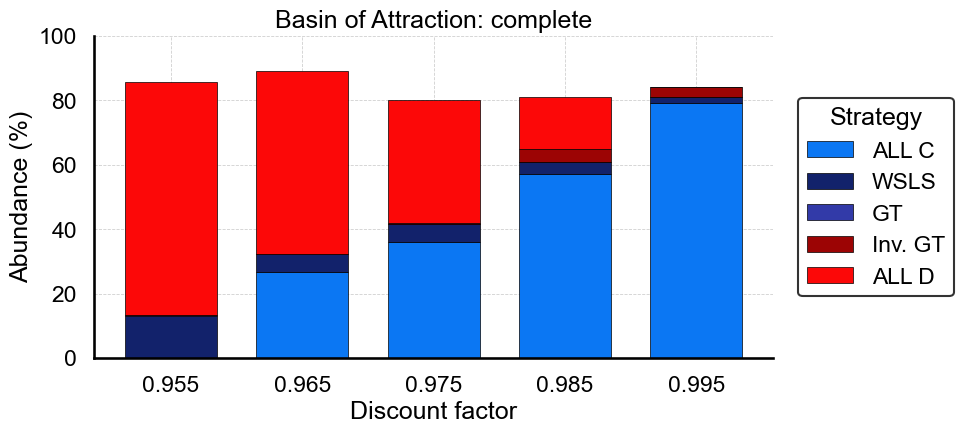

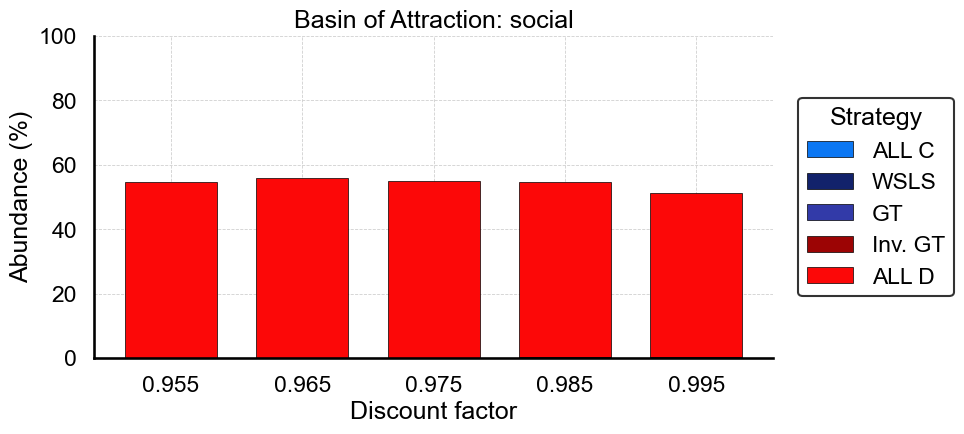

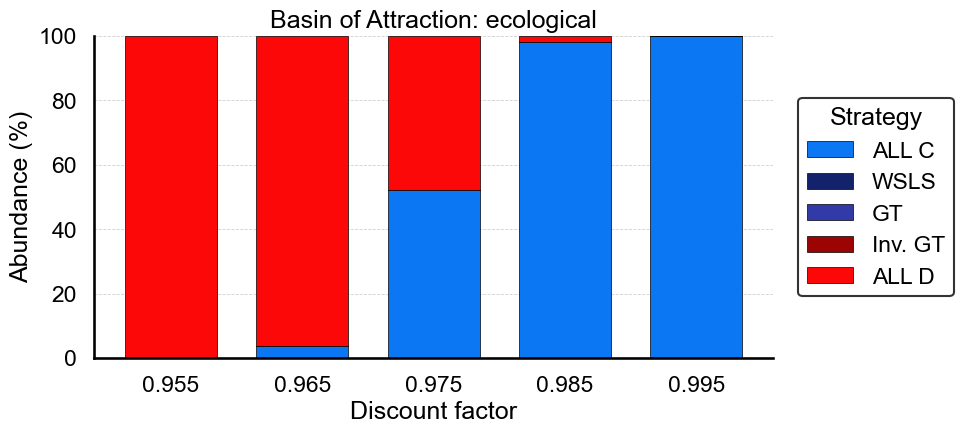

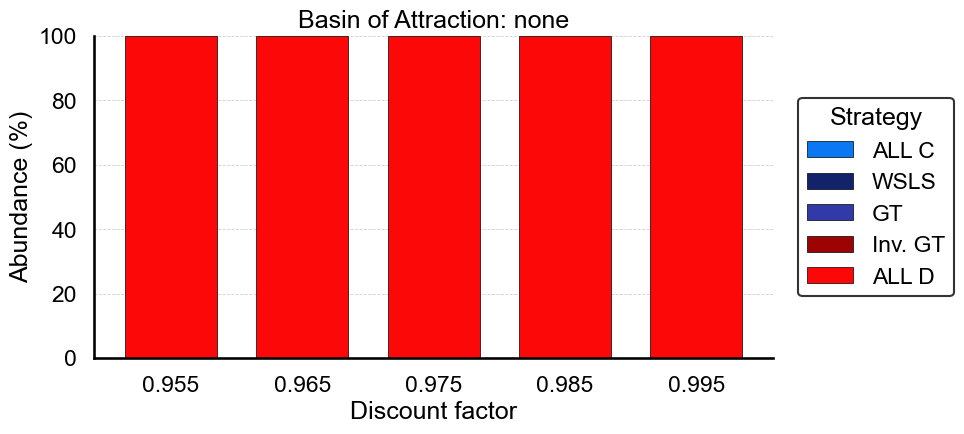

In [113]:
pure_and_mixed_strategies = ['ALL C', 'WSLS', 'GT', 'Almost ALL C', 'Almost WSLS', 'Almost GT', 'Inv. GT', 'ALL D', 'Almost Inv. GT', 'Almost ALL D']
pure_strategies = ['ALL C', 'WSLS', 'GT', 'Inv. GT', 'ALL D']

plot_basin_of_attraction([0.955, 0.965, 0.975, 0.985, 0.995], [6.5], pure_strategies)